<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/Optimization_Techniques_Exercise_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: collecting Census/BTS data and creating the supply-chain dataset.

In [21]:
import requests
import pandas as pd

CENSUS_API_KEY = "d2e25251c5198be698967f89f7c8dbbb798ada88"

url = "https://api.census.gov/data/2024/acs/acs1"

params = {
    "get": "NAME,B01001_001E",
    "for": "metropolitan statistical area/micropolitan statistical area:*",
    "key": CENSUS_API_KEY
}

response = requests.get(url, params=params, timeout=30)

print("Status:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print(response.text[:300])

Status: 200
Content-Type: application/json;charset=utf-8
[["NAME","B01001_001E","metropolitan statistical area/micropolitan statistical area"],
["Aberdeen, WA Micro Area","77893","10140"],
["Abilene, TX Metro Area","181969","10180"],
["Adrian, MI Micro Area","97746","10300"],
["Aguadilla, PR Metro Area","250969","10380"],
["Akron, OH Metro Area","702209",


In [23]:
data = response.json()

metro_population = pd.DataFrame(
    data[1:],
    columns=data[0]
)

metro_population = metro_population.rename(columns={
    "NAME": "region",
    "B01001_001E": "population",
    "metropolitan statistical area/micropolitan statistical area": "metro_code"
})

metro_population["population"] = pd.to_numeric(
    metro_population["population"]
)

metro_population = metro_population.sort_values(
    "population",
    ascending=False
)

metro_population.head(20)

,region,population,metro_code
340,"New York-Newark-Jersey City, NY-NJ Metro Area",19940274,35620
280,"Los Angeles-Long Beach-Anaheim, CA Metro Area",12927614,31080
87,"Chicago-Naperville-Elgin, IL-IN Metro Area",9406924,16980
116,"Dallas-Fort Worth-Arlington, TX Metro Area",8344032,19100
212,"Houston-Pasadena-The Woodlands, TX Metro Area",7796182,26420
305,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",6457988,33100
508,"Washington-Arlington-Alexandria, DC-VA-MD-WV M...",6437907,47900
28,"Atlanta-Sandy Springs-Roswell, GA Metro Area",6409047,12060
369,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD Me...",6330422,37980
370,"Phoenix-Mesa-Chandler, AZ Metro Area",5186958,38060


In [24]:
target_cities = [
    "New York",
    "Los Angeles",
    "Chicago",
    "Dallas-Fort Worth",
    "Houston",
    "Atlanta",
    "Miami",
    "Phoenix",
    "Seattle",
    "Denver",
    "Boston",
    "Las Vegas"
]

selected_regions = metro_population[
    metro_population["region"].apply(
        lambda x: any(city.lower() in x.lower() for city in target_cities)
    )
].copy()

selected_regions[
    ["region", "population", "metro_code"]
].sort_values("population", ascending=False)

,region,population,metro_code
340,"New York-Newark-Jersey City, NY-NJ Metro Area",19940274,35620
280,"Los Angeles-Long Beach-Anaheim, CA Metro Area",12927614,31080
87,"Chicago-Naperville-Elgin, IL-IN Metro Area",9406924,16980
116,"Dallas-Fort Worth-Arlington, TX Metro Area",8344032,19100
212,"Houston-Pasadena-The Woodlands, TX Metro Area",7796182,26420
305,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",6457988,33100
28,"Atlanta-Sandy Springs-Roswell, GA Metro Area",6409047,12060
370,"Phoenix-Mesa-Chandler, AZ Metro Area",5186958,38060
58,"Boston-Cambridge-Newton, MA-NH Metro Area",5025517,14460
442,"Seattle-Tacoma-Bellevue, WA Metro Area",4145494,42660


In [25]:
TOTAL_MONTHLY_DEMAND = 120000

selected_regions["demand_weight"] = (
    selected_regions["population"]
    / selected_regions["population"].sum()
)

selected_regions["monthly_demand"] = (
    selected_regions["demand_weight"]
    * TOTAL_MONTHLY_DEMAND
).round().astype(int)

selected_regions[
    ["region", "population", "demand_weight", "monthly_demand"]
].sort_values("monthly_demand", ascending=False)

,region,population,demand_weight,monthly_demand
340,"New York-Newark-Jersey City, NY-NJ Metro Area",19940274,0.218909,26269
280,"Los Angeles-Long Beach-Anaheim, CA Metro Area",12927614,0.141922,17031
87,"Chicago-Naperville-Elgin, IL-IN Metro Area",9406924,0.103271,12393
116,"Dallas-Fort Worth-Arlington, TX Metro Area",8344032,0.091603,10992
212,"Houston-Pasadena-The Woodlands, TX Metro Area",7796182,0.085588,10271
305,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",6457988,0.070897,8508
28,"Atlanta-Sandy Springs-Roswell, GA Metro Area",6409047,0.070360,8443
370,"Phoenix-Mesa-Chandler, AZ Metro Area",5186958,0.056944,6833
58,"Boston-Cambridge-Newton, MA-NH Metro Area",5025517,0.055171,6621
442,"Seattle-Tacoma-Bellevue, WA Metro Area",4145494,0.045510,5461


In [26]:
print("Number of regions:", len(selected_regions))
print("Total population:", selected_regions["population"].sum())
print("Total modeled monthly demand:", selected_regions["monthly_demand"].sum())

Number of regions: 12
Total population: 91089413
Total modeled monthly demand: 120001


# Step 2: Load BTS Freight Analysis Framework (FAF6) data

In [29]:
import requests

meta_url = "https://rosap.ntl.bts.gov/view/dot/92758/dot_92758_DS1.json"

r = requests.get(meta_url, timeout=60)

print("Status:", r.status_code)
print("Content-Type:", r.headers.get("content-type"))
print(r.text[:1000])

Status: 200
Content-Type: application/json
{
  "$schema": "https://resources.data.gov/schemas/dcat-us/v1.1/schema/catalog.json",
  "conformsTo": "https://project-open-data.cio.gov/v1.1/schema",
  "@type": "dcat:Catalog",
  "@context": "https://project-open-data.cio.gov/v1.1/schema/catalog.jsonld",
  "dataset": [
    {
      "@type": "dcat:Dataset",
      "accessLevel": "public",
      "bureauCode": [
        "021:04"
      ],
      "contactPoint": {
        "fn": "National Transportation Library Data Curator",
        "hasEmail": "mailto:NTLDataCurator@dot.gov",
        "@type": "vcard:Contact"
      },
      "dataQuality": true,
      "description": "The Freight Analysis Framework (FAF) creates a comprehensive picture of freight movement among states and major metropolitan areas by all modes of transportation. The FAF integrates data from a variety of sources. Starting with data from the Commodity Flow Survey (CFS) and international trade data from the Census Bureau, FAF incorporates 

In [30]:
meta = r.json()

type(meta)

dict

In [31]:
meta

{'$schema': 'https://resources.data.gov/schemas/dcat-us/v1.1/schema/catalog.json',
 'conformsTo': 'https://project-open-data.cio.gov/v1.1/schema',
 '@type': 'dcat:Catalog',
 '@context': 'https://project-open-data.cio.gov/v1.1/schema/catalog.jsonld',
 'dataset': [{'@type': 'dcat:Dataset',
   'accessLevel': 'public',
   'bureauCode': ['021:04'],
   'contactPoint': {'fn': 'National Transportation Library Data Curator',
    'hasEmail': 'mailto:NTLDataCurator@dot.gov',
    '@type': 'vcard:Contact'},
   'dataQuality': True,
   'description': 'The Freight Analysis Framework (FAF) creates a comprehensive picture of freight movement among states and major metropolitan areas by all modes of transportation. The FAF integrates data from a variety of sources. Starting with data from the Commodity Flow Survey (CFS) and international trade data from the Census Bureau, FAF incorporates data from agriculture, extraction, utility, construction, service, and other sectors. The FAF6 Regional Database of t

In [39]:
from google.colab import files

uploaded = files.upload()

Saving FAF6.0.zip to FAF6.0.zip


In [45]:
import zipfile
import os

if os.path.exists("faf6/FAF6.0_State.csv"):
    os.remove("faf6/FAF6.0_State.csv")
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("faf6")

for root, dirs, files_ in os.walk("faf6"):
    for file in files_:
        print(os.path.join(root, file))

faf6/FAF6.0.csv
faf6/FAF6_Metadata.xlsx


In [53]:
metadata_file = "faf6/FAF6_Metadata.xlsx"

xls = pd.ExcelFile(metadata_file)

print("Sheet names:")
print(xls.sheet_names)

Sheet names:
['Data Dictionary', 'State', 'FAF Zone (Domestic)', 'FAF Zone (Foreign)', 'Commodity (SCTG2)', 'Mode', 'Trade Type', 'Distance Band']


In [54]:
for sheet in xls.sheet_names:
    print("\nSHEET:", sheet)
    display(pd.read_excel(metadata_file, sheet_name=sheet).head(10))


SHEET: Data Dictionary


,"U.S. Department of Transportation, Bureau of Transportation Statics (BTS), Freight Analysis Framework Version 6 (FAF6)",Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,Field,Description,Link (Tab),NaN
2,fr_orig,Foreign region of shipment origin,FAF Zone (Foreign),NaN
3,dms_orig,FAF region or state where a freight movement b...,FAF Zone (Domestic),State
4,dms_dest,FAF region or state where a freight movement e...,FAF Zone (Domestic),State
5,fr_dest,Foreign region of shipment destination,FAF Zone (Foreign),NaN
6,sctg2,2-digit level of the Standard Classification o...,Commodity (SCTG2),NaN
7,fr_inmode,Mode used between a foreign region and the US ...,Mode,NaN
8,dms_mode,Mode used between domestic origins and destina...,Mode,NaN
9,fr_outmode,Mode used between the US exit region and forei...,Mode,NaN



SHEET: State


,Numeric Label,Description
0,1,Alabama
1,2,Alaska
2,4,Arizona
3,5,Arkansas
4,6,California
5,8,Colorado
6,9,Connecticut
7,10,Delaware
8,11,Washington DC
9,12,Florida



SHEET: FAF Zone (Domestic)


...

,Numeric Label,Description
0,1,Truck (include customer pick-up)
1,2,Rail
2,3,Water
3,4,Air (include truck-air)
4,5,Multiple modes & mail
5,6,Pipeline
6,7,Other and unknown
7,8,No domestic mode



SHEET: Trade Type


,Numeric Label,Description
0,1,Domestic flows (freight shipments moved from U...
1,2,Import flows (freight shipments moved from for...
2,3,Export flows (freight shipments moved from US ...



SHEET: Distance Band


,Numeric Label,Description
0,1,Below 100 miles
1,2,100 - 249 miles
2,3,250 - 499 miles
3,4,500 - 749 miles
4,5,750 - 999 miles
5,6,"1,000 - 1,499 miles"
6,7,"1,500 - 2,000 miles"
7,8,"Over 2,000 miles"


In [46]:
csv_files = []

for root, dirs, files_ in os.walk("faf6"):
    for file in files_:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print(csv_files)

['faf6/FAF6.0.csv']


In [47]:
faf = pd.read_csv("faf6/FAF6.0.csv")

print("Rows:", len(faf))
print("Columns:", faf.columns.tolist())
faf.dtypes
faf.head()

Rows: 1921887
Columns: ['fr_orig', 'dms_orig', 'dms_dest', 'fr_dest', 'fr_inmode', 'dms_mode', 'fr_outmode', 'sctg2', 'trade_type', 'tons_2022', 'value_2022']


,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,tons_2022,value_2022
0,NaN,11,11,NaN,NaN,1,NaN,1,1,16.544030,40.397131
1,NaN,11,12,NaN,NaN,1,NaN,1,1,0.069420,0.169509
2,NaN,11,19,NaN,NaN,1,NaN,1,1,5.830945,14.237974
3,NaN,11,50,NaN,NaN,1,NaN,1,1,4.128398,10.080702
4,NaN,11,121,NaN,NaN,1,NaN,1,1,0.224626,0.548490


In [48]:
  faf_truck = faf[
    (faf["trade_type"] == 1) &   # domestic only
    (faf["dms_mode"] == 1)       # truck
].copy()

print("Domestic truck rows:", len(faf_truck))

faf_truck.head()

Domestic truck rows: 317451


,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,tons_2022,value_2022
0,NaN,11,11,NaN,NaN,1,NaN,1,1,16.544030,40.397131
1,NaN,11,12,NaN,NaN,1,NaN,1,1,0.069420,0.169509
2,NaN,11,19,NaN,NaN,1,NaN,1,1,5.830945,14.237974
3,NaN,11,50,NaN,NaN,1,NaN,1,1,4.128398,10.080702
4,NaN,11,121,NaN,NaN,1,NaN,1,1,0.224626,0.548490


In [49]:
origin_summary = (
    faf_truck
    .groupby("dms_orig", as_index=False)
    .agg(
        total_tons=("tons_2022", "sum"),
        total_value=("value_2022", "sum")
    )
    .sort_values("total_tons", ascending=False)
)

origin_summary.head(20)

,dms_orig,total_tons,total_value
8,61,451846.820715,918947.069529
4,41,311002.140825,169981.612746
114,484,300018.702659,427527.031024
119,489,258830.406341,275127.201412
33,171,254626.595681,458643.385504
41,199,253591.560455,195837.919978
35,179,234493.260690,196923.539555
101,429,221242.385710,273847.139948
118,488,214154.180536,159431.247747
132,559,196498.108382,239018.185896


In [50]:
destination_summary = (
    faf_truck
    .groupby("dms_dest", as_index=False)
    .agg(
        total_tons=("tons_2022", "sum"),
        total_value=("value_2022", "sum")
    )
    .sort_values("total_tons", ascending=False)
)

destination_summary.head(20)

,dms_dest,total_tons,total_value
8,61,411619.328376,771073.637433
4,41,312194.575088,180521.239493
114,484,310870.016610,415357.974661
33,171,273707.087542,433043.808348
119,489,263835.536862,318347.437971
41,199,257171.110294,187411.800512
35,179,207501.737484,188936.103587
11,64,204003.184873,307310.962670
118,488,195639.830324,149392.955951
116,486,194723.744039,342146.087183


In [51]:
metadata_file = "faf6/FAF6_Metadata.xlsx"

xls = pd.ExcelFile(metadata_file)

print(xls.sheet_names)

['Data Dictionary', 'State', 'FAF Zone (Domestic)', 'FAF Zone (Foreign)', 'Commodity (SCTG2)', 'Mode', 'Trade Type', 'Distance Band']


In [52]:
for sheet in xls.sheet_names:
    print("\nSHEET:", sheet)
    display(pd.read_excel(metadata_file, sheet_name=sheet).head(10))


SHEET: Data Dictionary


,"U.S. Department of Transportation, Bureau of Transportation Statics (BTS), Freight Analysis Framework Version 6 (FAF6)",Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,Field,Description,Link (Tab),NaN
2,fr_orig,Foreign region of shipment origin,FAF Zone (Foreign),NaN
3,dms_orig,FAF region or state where a freight movement b...,FAF Zone (Domestic),State
4,dms_dest,FAF region or state where a freight movement e...,FAF Zone (Domestic),State
5,fr_dest,Foreign region of shipment destination,FAF Zone (Foreign),NaN
6,sctg2,2-digit level of the Standard Classification o...,Commodity (SCTG2),NaN
7,fr_inmode,Mode used between a foreign region and the US ...,Mode,NaN
8,dms_mode,Mode used between domestic origins and destina...,Mode,NaN
9,fr_outmode,Mode used between the US exit region and forei...,Mode,NaN



SHEET: State


,Numeric Label,Description
0,1,Alabama
1,2,Alaska
2,4,Arizona
3,5,Arkansas
4,6,California
5,8,Colorado
6,9,Connecticut
7,10,Delaware
8,11,Washington DC
9,12,Florida



SHEET: FAF Zone (Domestic)


...

,Numeric Label,Description
0,1,Truck (include customer pick-up)
1,2,Rail
2,3,Water
3,4,Air (include truck-air)
4,5,Multiple modes & mail
5,6,Pipeline
6,7,Other and unknown
7,8,No domestic mode



SHEET: Trade Type


,Numeric Label,Description
0,1,Domestic flows (freight shipments moved from U...
1,2,Import flows (freight shipments moved from for...
2,3,Export flows (freight shipments moved from US ...



SHEET: Distance Band


,Numeric Label,Description
0,1,Below 100 miles
1,2,100 - 249 miles
2,3,250 - 499 miles
3,4,500 - 749 miles
4,5,750 - 999 miles
5,6,"1,000 - 1,499 miles"
6,7,"1,500 - 2,000 miles"
7,8,"Over 2,000 miles"


In [55]:
faf_zones = pd.read_excel(
    metadata_file,
    sheet_name="FAF Zone (Domestic)"
)

faf_zones = faf_zones.rename(columns={
    "Numeric Label": "faf_zone",
    "Short Description": "faf_zone_short",
    "Long Description": "faf_zone_long"
})

faf_zones.head()

,faf_zone,faf_zone_short,faf_zone_long
0,11,Birmingham AL,"Birmingham-Hoover-Talladega, AL CFS Area"
1,12,Mobile AL,"Mobile-Daphne-Fairhope, AL CFS Area"
2,19,Rest of AL,Remainder of Alabama
3,20,Alaska,Alaska
4,41,Phoenix AZ,"Phoenix-Mesa, AZ CFS Area"


In [56]:
faf_truck = faf[
    (faf["trade_type"] == 1) &
    (faf["dms_mode"] == 1)
].copy()

print("Domestic truck rows:", len(faf_truck))

Domestic truck rows: 317451


In [57]:
origin_lookup = faf_zones.rename(columns={
    "faf_zone": "dms_orig",
    "faf_zone_short": "origin_name",
    "faf_zone_long": "origin_long"
})

dest_lookup = faf_zones.rename(columns={
    "faf_zone": "dms_dest",
    "faf_zone_short": "destination_name",
    "faf_zone_long": "destination_long"
})

faf_truck_named = (
    faf_truck
    .merge(
        origin_lookup[["dms_orig", "origin_name", "origin_long"]],
        on="dms_orig",
        how="left"
    )
    .merge(
        dest_lookup[["dms_dest", "destination_name", "destination_long"]],
        on="dms_dest",
        how="left"
    )
)

faf_truck_named.head()

,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,tons_2022,value_2022,origin_name,origin_long,destination_name,destination_long
0,NaN,11,11,NaN,NaN,1,NaN,1,1,16.544030,40.397131,Birmingham AL,"Birmingham-Hoover-Talladega, AL CFS Area",Birmingham AL,"Birmingham-Hoover-Talladega, AL CFS Area"
1,NaN,11,12,NaN,NaN,1,NaN,1,1,0.069420,0.169509,Birmingham AL,"Birmingham-Hoover-Talladega, AL CFS Area",Mobile AL,"Mobile-Daphne-Fairhope, AL CFS Area"
2,NaN,11,19,NaN,NaN,1,NaN,1,1,5.830945,14.237974,Birmingham AL,"Birmingham-Hoover-Talladega, AL CFS Area",Rest of AL,Remainder of Alabama
3,NaN,11,50,NaN,NaN,1,NaN,1,1,4.128398,10.080702,Birmingham AL,"Birmingham-Hoover-Talladega, AL CFS Area",Arkansas,Arkansas
4,NaN,11,121,NaN,NaN,1,NaN,1,1,0.224626,0.548490,Birmingham AL,"Birmingham-Hoover-Talladega, AL CFS Area",Jacksonville FL-GA (FL Part),"Jacksonville-St. Marys-Palatka, FL-GA CFS Are..."


In [58]:
origin_summary = (
    faf_truck_named
    .groupby(["dms_orig", "origin_name"], as_index=False)
    .agg(
        total_tons=("tons_2022", "sum"),
        total_value=("value_2022", "sum")
    )
    .sort_values("total_tons", ascending=False)
)

origin_summary.head(25)

,dms_orig,origin_name,total_tons,total_value
8,61,Los Angeles CA,451846.820715,918947.069529
4,41,Phoenix AZ,311002.140825,169981.612746
114,484,Dallas-Fort Worth TX-OK (TX Part),300018.702659,427527.031024
119,489,Rest of TX,258830.406341,275127.201412
33,171,Chicago IL-IN-WI (IL Part),254626.595681,458643.385504
41,199,Rest of IA,253591.560455,195837.919978
35,179,Rest of IL,234493.260690,196923.539555
101,429,Rest of PA,221242.385710,273847.139948
118,488,San Antonio TX,214154.180536,159431.247747
132,559,Rest of WI,196498.108382,239018.185896


In [59]:
destination_summary = (
    faf_truck_named
    .groupby(["dms_dest", "destination_name"], as_index=False)
    .agg(
        total_tons=("tons_2022", "sum"),
        total_value=("value_2022", "sum")
    )
    .sort_values("total_tons", ascending=False)
)

destination_summary.head(25)

,dms_dest,destination_name,total_tons,total_value
8,61,Los Angeles CA,411619.328376,771073.637433
4,41,Phoenix AZ,312194.575088,180521.239493
114,484,Dallas-Fort Worth TX-OK (TX Part),310870.016610,415357.974661
33,171,Chicago IL-IN-WI (IL Part),273707.087542,433043.808348
119,489,Rest of TX,263835.536862,318347.437971
41,199,Rest of IA,257171.110294,187411.800512
35,179,Rest of IL,207501.737484,188936.103587
11,64,San Francisco CA,204003.184873,307310.962670
118,488,San Antonio TX,195639.830324,149392.955951
116,486,Houston TX,194723.744039,342146.087183


# Step 3: Map Census demand regions to FAF freight zones

In [60]:
region_to_faf = {
    "New York": [341, 363],       # NJ part + NY part
    "Los Angeles": [61],
    "Chicago": [171],
    "Dallas-Fort Worth": [484],
    "Houston": [486],
    "Atlanta": [131],
    "Miami": [122],
    "Phoenix": [41],
    "Seattle": [531],
    "Denver": [81],
    "Boston": [251],
    "Las Vegas": [321]
}

In [61]:
check_codes = [
    341, 363, 61, 171, 484, 486,
    131, 122, 41, 531, 81, 251, 321
]

faf_zones[
    faf_zones["faf_zone"].isin(check_codes)
][["faf_zone", "faf_zone_short", "faf_zone_long"]].sort_values("faf_zone")

,faf_zone,faf_zone_short,faf_zone_long
4,41,Phoenix AZ,"Phoenix-Mesa, AZ CFS Area"
8,61,Los Angeles CA,"Los Angeles-Long Beach, CA CFS Area"
14,81,Denver CO,"Denver-Aurora, CO CFS Area"
23,122,Miami FL,"Miami-Port St. Lucie-Fort Lauderdale, FL CFS ..."
27,131,Atlanta GA,"Atlanta-Athens-Clarke County-Sandy Springs, GA..."
33,171,Chicago IL-IN-WI (IL Part),"Chicago-Naperville, IL-IN-WI CFS Area (IL Part)"
56,251,Boston MA-RI-NH-CT (MA Part),"Boston-Worcester-Providence, MA-RI-NH-CT CFS ..."
70,321,Las Vegas NV,"Las Vegas-Henderson, NV CFS Area"
74,341,New York NY-NJ-CT-PA (NJ Part),"New York-Newark, NY-NJ-CT-PA CFS Area (NJ Part)"
79,363,New York NY-NJ-CT-PA (NY Part),"New York-Newark, NY-NJ-CT-PA CFS Area (NY Part)"


In [62]:
market_freight = []

for market, codes in region_to_faf.items():

    outbound = origin_summary[
        origin_summary["dms_orig"].isin(codes)
    ]["total_tons"].sum()

    inbound = destination_summary[
        destination_summary["dms_dest"].isin(codes)
    ]["total_tons"].sum()

    market_freight.append({
        "market": market,
        "outbound_tons": outbound,
        "inbound_tons": inbound,
        "total_freight_tons": outbound + inbound
    })

market_freight = pd.DataFrame(market_freight)

market_freight.sort_values(
    "total_freight_tons",
    ascending=False
)

,market,outbound_tons,inbound_tons,total_freight_tons
1,Los Angeles,451846.820715,411619.328376,863466.149091
0,New York,308615.245799,335931.656852,644546.902651
7,Phoenix,311002.140825,312194.575088,623196.715913
3,Dallas-Fort Worth,300018.702659,310870.016610,610888.719269
2,Chicago,254626.595681,273707.087542,528333.683223
4,Houston,177130.012335,194723.744039,371853.756374
5,Atlanta,172011.386821,188080.400226,360091.787047
10,Boston,133514.964460,146483.590426,279998.554886
6,Miami,124758.099261,141554.808052,266312.907313
9,Denver,89011.252805,93403.163326,182414.416131


In [63]:
city_patterns = {
    "New York": "New York",
    "Los Angeles": "Los Angeles",
    "Chicago": "Chicago",
    "Dallas-Fort Worth": "Dallas-Fort Worth",
    "Houston": "Houston",
    "Atlanta": "Atlanta",
    "Miami": "Miami",
    "Phoenix": "Phoenix",
    "Seattle": "Seattle",
    "Denver": "Denver",
    "Boston": "Boston",
    "Las Vegas": "Las Vegas"
}

def assign_market(region):
    for market, pattern in city_patterns.items():
        if pattern.lower() in region.lower():
            return market
    return None

selected_regions["market"] = selected_regions["region"].apply(assign_market)

In [64]:
network_regions = selected_regions.merge(
    market_freight,
    on="market",
    how="left"
)

network_regions[
    [
        "market",
        "population",
        "monthly_demand",
        "outbound_tons",
        "inbound_tons",
        "total_freight_tons"
    ]
].sort_values(
    "total_freight_tons",
    ascending=False
)

,market,population,monthly_demand,outbound_tons,inbound_tons,total_freight_tons
1,Los Angeles,12927614,17031,451846.820715,411619.328376,863466.149091
0,New York,19940274,26269,308615.245799,335931.656852,644546.902651
7,Phoenix,5186958,6833,311002.140825,312194.575088,623196.715913
3,Dallas-Fort Worth,8344032,10992,300018.702659,310870.016610,610888.719269
2,Chicago,9406924,12393,254626.595681,273707.087542,528333.683223
4,Houston,7796182,10271,177130.012335,194723.744039,371853.756374
6,Atlanta,6409047,8443,172011.386821,188080.400226,360091.787047
8,Boston,5025517,6621,133514.964460,146483.590426,279998.554886
5,Miami,6457988,8508,124758.099261,141554.808052,266312.907313
10,Denver,3050512,4019,89011.252805,93403.163326,182414.416131


# Step 3: Map Census demand regions to FAF freight zones

In [65]:
region_to_faf = {
    "New York": [341, 363],
    "Los Angeles": [61],
    "Chicago": [171],
    "Dallas-Fort Worth": [484],
    "Houston": [486],
    "Atlanta": [131],
    "Miami": [122],
    "Phoenix": [41],
    "Seattle": [531],
    "Denver": [81],
    "Boston": [251],
    "Las Vegas": [321]
}

In [66]:
check_codes = [
    341, 363, 61, 171, 484, 486,
    131, 122, 41, 531, 81, 251, 321
]

faf_zones[
    faf_zones["faf_zone"].isin(check_codes)
][["faf_zone", "faf_zone_short", "faf_zone_long"]].sort_values("faf_zone")

,faf_zone,faf_zone_short,faf_zone_long
4,41,Phoenix AZ,"Phoenix-Mesa, AZ CFS Area"
8,61,Los Angeles CA,"Los Angeles-Long Beach, CA CFS Area"
14,81,Denver CO,"Denver-Aurora, CO CFS Area"
23,122,Miami FL,"Miami-Port St. Lucie-Fort Lauderdale, FL CFS ..."
27,131,Atlanta GA,"Atlanta-Athens-Clarke County-Sandy Springs, GA..."
33,171,Chicago IL-IN-WI (IL Part),"Chicago-Naperville, IL-IN-WI CFS Area (IL Part)"
56,251,Boston MA-RI-NH-CT (MA Part),"Boston-Worcester-Providence, MA-RI-NH-CT CFS ..."
70,321,Las Vegas NV,"Las Vegas-Henderson, NV CFS Area"
74,341,New York NY-NJ-CT-PA (NJ Part),"New York-Newark, NY-NJ-CT-PA CFS Area (NJ Part)"
79,363,New York NY-NJ-CT-PA (NY Part),"New York-Newark, NY-NJ-CT-PA CFS Area (NY Part)"


In [67]:
market_freight = []

for market, codes in region_to_faf.items():

    outbound = origin_summary[
        origin_summary["dms_orig"].isin(codes)
    ]["total_tons"].sum()

    inbound = destination_summary[
        destination_summary["dms_dest"].isin(codes)
    ]["total_tons"].sum()

    market_freight.append({
        "market": market,
        "outbound_tons": outbound,
        "inbound_tons": inbound,
        "total_freight_tons": outbound + inbound
    })

market_freight = pd.DataFrame(market_freight)

market_freight.sort_values(
    "total_freight_tons",
    ascending=False
)

,market,outbound_tons,inbound_tons,total_freight_tons
1,Los Angeles,451846.820715,411619.328376,863466.149091
0,New York,308615.245799,335931.656852,644546.902651
7,Phoenix,311002.140825,312194.575088,623196.715913
3,Dallas-Fort Worth,300018.702659,310870.016610,610888.719269
2,Chicago,254626.595681,273707.087542,528333.683223
4,Houston,177130.012335,194723.744039,371853.756374
5,Atlanta,172011.386821,188080.400226,360091.787047
10,Boston,133514.964460,146483.590426,279998.554886
6,Miami,124758.099261,141554.808052,266312.907313
9,Denver,89011.252805,93403.163326,182414.416131


In [68]:
city_patterns = {
    "New York": "New York",
    "Los Angeles": "Los Angeles",
    "Chicago": "Chicago",
    "Dallas-Fort Worth": "Dallas-Fort Worth",
    "Houston": "Houston",
    "Atlanta": "Atlanta",
    "Miami": "Miami",
    "Phoenix": "Phoenix",
    "Seattle": "Seattle",
    "Denver": "Denver",
    "Boston": "Boston",
    "Las Vegas": "Las Vegas"
}

def assign_market(region):
    for market, pattern in city_patterns.items():
        if pattern.lower() in region.lower():
            return market
    return None

selected_regions["market"] = selected_regions["region"].apply(assign_market)

In [69]:
network_regions = selected_regions.merge(
    market_freight,
    on="market",
    how="left"
)

network_regions[
    [
        "market",
        "population",
        "monthly_demand",
        "outbound_tons",
        "inbound_tons",
        "total_freight_tons"
    ]
].sort_values(
    "total_freight_tons",
    ascending=False
)

,market,population,monthly_demand,outbound_tons,inbound_tons,total_freight_tons
1,Los Angeles,12927614,17031,451846.820715,411619.328376,863466.149091
0,New York,19940274,26269,308615.245799,335931.656852,644546.902651
7,Phoenix,5186958,6833,311002.140825,312194.575088,623196.715913
3,Dallas-Fort Worth,8344032,10992,300018.702659,310870.016610,610888.719269
2,Chicago,9406924,12393,254626.595681,273707.087542,528333.683223
4,Houston,7796182,10271,177130.012335,194723.744039,371853.756374
6,Atlanta,6409047,8443,172011.386821,188080.400226,360091.787047
8,Boston,5025517,6621,133514.964460,146483.590426,279998.554886
5,Miami,6457988,8508,124758.099261,141554.808052,266312.907313
10,Denver,3050512,4019,89011.252805,93403.163326,182414.416131


# Step 4: Build candidate warehouse network and transportation matrix

In [70]:
market_coordinates = {
    "New York": (40.7128, -74.0060),
    "Los Angeles": (34.0522, -118.2437),
    "Chicago": (41.8781, -87.6298),
    "Dallas-Fort Worth": (32.7767, -96.7970),
    "Houston": (29.7604, -95.3698),
    "Atlanta": (33.7490, -84.3880),
    "Miami": (25.7617, -80.1918),
    "Phoenix": (33.4484, -112.0740),
    "Seattle": (47.6062, -122.3321),
    "Denver": (39.7392, -104.9903),
    "Boston": (42.3601, -71.0589),
    "Las Vegas": (36.1699, -115.1398)
}

network_regions["latitude"] = network_regions["market"].map(
    lambda x: market_coordinates[x][0]
)

network_regions["longitude"] = network_regions["market"].map(
    lambda x: market_coordinates[x][1]
)

network_regions[
    ["market", "latitude", "longitude", "monthly_demand"]
]

,market,latitude,longitude,monthly_demand
0,New York,40.7128,-74.0060,26269
1,Los Angeles,34.0522,-118.2437,17031
2,Chicago,41.8781,-87.6298,12393
3,Dallas-Fort Worth,32.7767,-96.7970,10992
4,Houston,29.7604,-95.3698,10271
5,Miami,25.7617,-80.1918,8508
6,Atlanta,33.7490,-84.3880,8443
7,Phoenix,33.4484,-112.0740,6833
8,Boston,42.3601,-71.0589,6621
9,Seattle,47.6062,-122.3321,5461


In [71]:
min_capacity = 18000
max_capacity = 40000

freight_min = network_regions["total_freight_tons"].min()
freight_max = network_regions["total_freight_tons"].max()

network_regions["capacity"] = (
    min_capacity
    +
    (
        (network_regions["total_freight_tons"] - freight_min)
        / (freight_max - freight_min)
    )
    * (max_capacity - min_capacity)
).round().astype(int)

network_regions[
    ["market", "monthly_demand", "total_freight_tons", "capacity"]
].sort_values("capacity", ascending=False)

,market,monthly_demand,total_freight_tons,capacity
1,Los Angeles,17031,863466.149091,40000
0,New York,26269,644546.902651,33879
7,Phoenix,6833,623196.715913,33282
3,Dallas-Fort Worth,10992,610888.719269,32938
2,Chicago,12393,528333.683223,30629
4,Houston,10271,371853.756374,26254
6,Atlanta,8443,360091.787047,25925
8,Boston,6621,279998.554886,23686
5,Miami,8508,266312.907313,23303
10,Denver,4019,182414.416131,20957


In [72]:
network_regions["fixed_cost"] = (
    60000
    +
    40000
    * (
        network_regions["population"]
        / network_regions["population"].max()
    )
).round().astype(int)

network_regions[
    ["market", "population", "capacity", "fixed_cost"]
].sort_values("fixed_cost", ascending=False)

,market,population,capacity,fixed_cost
0,New York,19940274,33879,100000
1,Los Angeles,12927614,40000,85933
2,Chicago,9406924,30629,78870
3,Dallas-Fort Worth,8344032,32938,76738
4,Houston,7796182,26254,75639
5,Miami,6457988,23303,72955
6,Atlanta,6409047,25925,72856
7,Phoenix,5186958,33282,70405
8,Boston,5025517,23686,70081
9,Seattle,4145494,20581,68316


# Step 5: Calculate distances

In [73]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1)
        * cos(lat2)
        * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [74]:
routes = []

for _, warehouse in network_regions.iterrows():

    for _, customer in network_regions.iterrows():

        distance = haversine(
            warehouse["latitude"],
            warehouse["longitude"],
            customer["latitude"],
            customer["longitude"]
        )

        routes.append({
            "warehouse": warehouse["market"],
            "customer": customer["market"],
            "distance_miles": distance
        })

routes = pd.DataFrame(routes)

routes.head(20)

,warehouse,customer,distance_miles
0,New York,New York,0.000000
1,New York,Los Angeles,2445.586607
2,New York,Chicago,711.037560
3,New York,Dallas-Fort Worth,1370.590631
4,New York,Houston,1417.577754
5,New York,Miami,1092.358640
6,New York,Atlanta,745.850595
7,New York,Phoenix,2139.838376
8,New York,Boston,190.209121
9,New York,Seattle,2401.954738


In [75]:
print("Number of routes:", len(routes))

Number of routes: 144


In [76]:
COST_PER_UNIT_MILE = 0.04
AVERAGE_TRUCK_SPEED = 50

In [77]:
routes["cost_per_unit"] = (
    routes["distance_miles"]
    * COST_PER_UNIT_MILE
)

routes["delivery_hours"] = (
    routes["distance_miles"]
    / AVERAGE_TRUCK_SPEED
)

routes.head()

,warehouse,customer,distance_miles,cost_per_unit,delivery_hours
0,New York,New York,0.000000,0.000000,0.000000
1,New York,Los Angeles,2445.586607,97.823464,48.911732
2,New York,Chicago,711.037560,28.441502,14.220751
3,New York,Dallas-Fort Worth,1370.590631,54.823625,27.411813
4,New York,Houston,1417.577754,56.703110,28.351555


In [78]:
MAX_DELIVERY_HOURS = 24

routes["route_allowed"] = (
    routes["delivery_hours"] <= MAX_DELIVERY_HOURS
)

routes[
    ["warehouse", "customer", "distance_miles",
     "delivery_hours", "route_allowed"]
].head(20)

,warehouse,customer,distance_miles,delivery_hours,route_allowed
0,New York,New York,0.000000,0.000000,True
1,New York,Los Angeles,2445.586607,48.911732,False
2,New York,Chicago,711.037560,14.220751,True
3,New York,Dallas-Fort Worth,1370.590631,27.411813,False
4,New York,Houston,1417.577754,28.351555,False
5,New York,Miami,1092.358640,21.847173,True
6,New York,Atlanta,745.850595,14.917012,True
7,New York,Phoenix,2139.838376,42.796768,False
8,New York,Boston,190.209121,3.804182,True
9,New York,Seattle,2401.954738,48.039095,False


In [79]:
print(
    routes["route_allowed"].value_counts()
)

route_allowed
True     76
False    68
Name: count, dtype: int64


# Step 6A: Mixed Integer Linear Programming (MILP)

In [80]:
!pip install pulp -q

In [81]:
import pulp

In [82]:
warehouses = network_regions["market"].tolist()
customers = network_regions["market"].tolist()

demand = dict(
    zip(
        network_regions["market"],
        network_regions["monthly_demand"]
    )
)

capacity = dict(
    zip(
        network_regions["market"],
        network_regions["capacity"]
    )
)

fixed_cost = dict(
    zip(
        network_regions["market"],
        network_regions["fixed_cost"]
    )
)

transport_cost = {
    (row["warehouse"], row["customer"]): row["cost_per_unit"]
    for _, row in routes.iterrows()
}

route_allowed = {
    (row["warehouse"], row["customer"]): row["route_allowed"]
    for _, row in routes.iterrows()
}

In [83]:
print("Total demand:", sum(demand.values()))
print("Total candidate capacity:", sum(capacity.values()))

Total demand: 120001
Total candidate capacity: 329434


In [84]:
model = pulp.LpProblem(
    "Supply_Chain_Network_Optimization",
    pulp.LpMinimize
)

In [85]:
open_warehouse = pulp.LpVariable.dicts(
    "OpenWarehouse",
    warehouses,
    cat="Binary"
)

In [86]:
shipment = pulp.LpVariable.dicts(
    "Shipment",
    (warehouses, customers),
    lowBound=0,
    cat="Continuous"
)

In [87]:
model += (
    pulp.lpSum(
        fixed_cost[w] * open_warehouse[w]
        for w in warehouses
    )
    +
    pulp.lpSum(
        transport_cost[(w, c)] * shipment[w][c]
        for w in warehouses
        for c in customers
    )
)

In [88]:
for c in customers:
    model += (
        pulp.lpSum(
            shipment[w][c]
            for w in warehouses
        )
        == demand[c],
        f"Demand_{c}"
    )

In [89]:
for w in warehouses:
    model += (
        pulp.lpSum(
            shipment[w][c]
            for c in customers
        )
        <= capacity[w] * open_warehouse[w],
        f"Capacity_{w}"
    )

In [90]:
for w in warehouses:
    for c in customers:
        if not route_allowed[(w, c)]:
            model += (
                shipment[w][c] == 0,
                f"DeliveryTime_{w}_{c}"
            )

In [91]:
solver = pulp.PULP_CBC_CMD(msg=True)

model.solve(solver)

1

In [92]:
print("Solver status:", pulp.LpStatus[model.status])
print("Objective value:", pulp.value(model.objective))

Solver status: Optimal
Objective value: 847078.5906834346


In [93]:
selected_warehouses = []

for w in warehouses:
    if open_warehouse[w].value() > 0.5:
        selected_warehouses.append(w)

print("Selected warehouses:")
for w in selected_warehouses:
    print("-", w)

Selected warehouses:
- New York
- Los Angeles
- Chicago
- Dallas-Fort Worth
- Houston
- Miami
- Atlanta
- Phoenix
- Seattle
- Denver


In [94]:
shipment_results = []

for w in warehouses:
    for c in customers:

        qty = shipment[w][c].value()

        if qty is not None and qty > 0.01:

            route_info = routes[
                (routes["warehouse"] == w) &
                (routes["customer"] == c)
            ].iloc[0]

            shipment_results.append({
                "warehouse": w,
                "customer": c,
                "units_shipped": qty,
                "distance_miles": route_info["distance_miles"],
                "delivery_hours": route_info["delivery_hours"],
                "cost_per_unit": route_info["cost_per_unit"],
                "transport_cost": (
                    qty * route_info["cost_per_unit"]
                )
            })

shipment_results = pd.DataFrame(shipment_results)

shipment_results.sort_values(
    ["warehouse", "customer"]
)

,warehouse,customer,units_shipped,distance_miles,delivery_hours,cost_per_unit,transport_cost
8,Atlanta,Atlanta,8443.0,0.000000,0.000000,0.000000,0.000000
4,Chicago,Chicago,12393.0,0.000000,0.000000,0.000000,0.000000
5,Dallas-Fort Worth,Dallas-Fort Worth,10992.0,0.000000,0.000000,0.000000,0.000000
11,Denver,Denver,4019.0,0.000000,0.000000,0.000000,0.000000
6,Houston,Houston,10271.0,0.000000,0.000000,0.000000,0.000000
3,Los Angeles,Las Vegas,3160.0,228.422525,4.568451,9.136901,28872.607203
2,Los Angeles,Los Angeles,17031.0,0.000000,0.000000,0.000000,0.000000
7,Miami,Miami,8508.0,0.000000,0.000000,0.000000,0.000000
1,New York,Boston,6621.0,190.209121,3.804182,7.608365,50374.983481
0,New York,New York,26269.0,0.000000,0.000000,0.000000,0.000000


In [95]:
warehouse_results = []

for w in warehouses:

    total_shipped = sum(
        shipment[w][c].value() or 0
        for c in customers
    )

    is_open = open_warehouse[w].value()

    warehouse_results.append({
        "warehouse": w,
        "open": int(round(is_open)),
        "capacity": capacity[w],
        "units_shipped": total_shipped,
        "utilization_pct": (
            total_shipped / capacity[w] * 100
            if capacity[w] > 0 else 0
        ),
        "fixed_cost": (
            fixed_cost[w]
            if is_open > 0.5 else 0
        )
    })

warehouse_results = pd.DataFrame(warehouse_results)

warehouse_results.sort_values(
    "units_shipped",
    ascending=False
)

,warehouse,open,capacity,units_shipped,utilization_pct,fixed_cost
0,New York,1,33879,32890.0,97.080788,100000
1,Los Angeles,1,40000,20191.0,50.477500,85933
2,Chicago,1,30629,12393.0,40.461654,78870
3,Dallas-Fort Worth,1,32938,10992.0,33.371789,76738
4,Houston,1,26254,10271.0,39.121658,75639
5,Miami,1,23303,8508.0,36.510321,72955
6,Atlanta,1,25925,8443.0,32.567020,72856
7,Phoenix,1,33282,6833.0,20.530617,70405
9,Seattle,1,20581,5461.0,26.534182,68316
10,Denver,1,20957,4019.0,19.177363,66119


In [96]:
total_fixed_cost = sum(
    fixed_cost[w] * open_warehouse[w].value()
    for w in warehouses
)

total_transport_cost = sum(
    transport_cost[(w, c)]
    * (shipment[w][c].value() or 0)
    for w in warehouses
    for c in customers
)

total_cost = total_fixed_cost + total_transport_cost

print(f"Fixed warehouse cost: ${total_fixed_cost:,.2f}")
print(f"Transportation cost: ${total_transport_cost:,.2f}")
print(f"Total network cost: ${total_cost:,.2f}")

Fixed warehouse cost: $767,831.00
Transportation cost: $79,247.59
Total network cost: $847,078.59


In [97]:
warehouse_results

,warehouse,open,capacity,units_shipped,utilization_pct,fixed_cost
0,New York,1,33879,32890.0,97.080788,100000
1,Los Angeles,1,40000,20191.0,50.477500,85933
2,Chicago,1,30629,12393.0,40.461654,78870
3,Dallas-Fort Worth,1,32938,10992.0,33.371789,76738
4,Houston,1,26254,10271.0,39.121658,75639
5,Miami,1,23303,8508.0,36.510321,72955
6,Atlanta,1,25925,8443.0,32.567020,72856
7,Phoenix,1,33282,6833.0,20.530617,70405
8,Boston,0,23686,0.0,0.000000,0
9,Seattle,1,20581,5461.0,26.534182,68316


In [98]:
shipment_results

,warehouse,customer,units_shipped,distance_miles,delivery_hours,cost_per_unit,transport_cost
0,New York,New York,26269.0,0.000000,0.000000,0.000000,0.000000
1,New York,Boston,6621.0,190.209121,3.804182,7.608365,50374.983481
2,Los Angeles,Los Angeles,17031.0,0.000000,0.000000,0.000000,0.000000
3,Los Angeles,Las Vegas,3160.0,228.422525,4.568451,9.136901,28872.607203
4,Chicago,Chicago,12393.0,0.000000,0.000000,0.000000,0.000000
5,Dallas-Fort Worth,Dallas-Fort Worth,10992.0,0.000000,0.000000,0.000000,0.000000
6,Houston,Houston,10271.0,0.000000,0.000000,0.000000,0.000000
7,Miami,Miami,8508.0,0.000000,0.000000,0.000000,0.000000
8,Atlanta,Atlanta,8443.0,0.000000,0.000000,0.000000,0.000000
9,Phoenix,Phoenix,6833.0,0.000000,0.000000,0.000000,0.000000


In [99]:
print(f"Total network cost: ${total_cost:,.2f}")

Total network cost: $847,078.59


# Step 6B: MILP with Regional Warehouse Limit

In [100]:
MAX_WAREHOUSES = 6

model2 = pulp.LpProblem(
    "Regional_Supply_Chain_Optimization",
    pulp.LpMinimize
)

open_warehouse2 = pulp.LpVariable.dicts(
    "OpenWarehouse",
    warehouses,
    cat="Binary"
)

shipment2 = pulp.LpVariable.dicts(
    "Shipment",
    (warehouses, customers),
    lowBound=0,
    cat="Continuous"
)

In [101]:
model2 += (
    pulp.lpSum(
        fixed_cost[w] * open_warehouse2[w]
        for w in warehouses
    )
    +
    pulp.lpSum(
        transport_cost[(w, c)] * shipment2[w][c]
        for w in warehouses
        for c in customers
    )
)

In [102]:
for c in customers:
    model2 += (
        pulp.lpSum(
            shipment2[w][c]
            for w in warehouses
        )
        == demand[c]
    )

In [103]:
for w in warehouses:
    model2 += (
        pulp.lpSum(
            shipment2[w][c]
            for c in customers
        )
        <= capacity[w] * open_warehouse2[w]
    )

In [104]:
for w in warehouses:
    for c in customers:
        if not route_allowed[(w, c)]:
            model2 += shipment2[w][c] == 0

In [105]:
model2 += (
    pulp.lpSum(
        open_warehouse2[w]
        for w in warehouses
    )
    <= MAX_WAREHOUSES
)

In [106]:
solver = pulp.PULP_CBC_CMD(msg=True)

model2.solve(solver)

print("Solver status:", pulp.LpStatus[model2.status])
print(
    "Total network cost:",
    f"${pulp.value(model2.objective):,.2f}"
)

Solver status: Optimal
Total network cost: $1,057,299.18


In [107]:
selected_warehouses2 = [
    w for w in warehouses
    if open_warehouse2[w].value() > 0.5
]

print("Selected warehouses:")

for w in selected_warehouses2:
    print("-", w)

Selected warehouses:
- New York
- Los Angeles
- Chicago
- Dallas-Fort Worth
- Miami
- Seattle


In [108]:
shipment_results2 = []

for w in warehouses:
    for c in customers:

        qty = shipment2[w][c].value()

        if qty is not None and qty > 0.01:

            route_info = routes[
                (routes["warehouse"] == w) &
                (routes["customer"] == c)
            ].iloc[0]

            shipment_results2.append({
                "warehouse": w,
                "customer": c,
                "units_shipped": qty,
                "distance_miles": route_info["distance_miles"],
                "delivery_hours": route_info["delivery_hours"],
                "transport_cost":
                    qty * route_info["cost_per_unit"]
            })

shipment_results2 = pd.DataFrame(shipment_results2)

shipment_results2

,warehouse,customer,units_shipped,distance_miles,delivery_hours,transport_cost
0,New York,New York,26269.0,0.000000,0.000000,0.000000
1,New York,Boston,6621.0,190.209121,3.804182,50374.983481
2,Los Angeles,Los Angeles,17031.0,0.000000,0.000000,0.000000
3,Los Angeles,Phoenix,6833.0,356.836219,7.136724,97530.475469
4,Los Angeles,Las Vegas,3160.0,228.422525,4.568451,28872.607203
5,Chicago,Chicago,12393.0,0.000000,0.000000,0.000000
6,Chicago,Atlanta,8443.0,588.759895,11.775198,198835.991794
7,Dallas-Fort Worth,Dallas-Fort Worth,10992.0,0.000000,0.000000,0.000000
8,Dallas-Fort Worth,Houston,10271.0,224.799669,4.495993,92356.695845
9,Dallas-Fort Worth,Denver,4019.0,662.580422,13.251608,106516.428666


# Step 7: Heuristic Optimization using a Genetic Algorithm

In [109]:
import random
import numpy as np

NUM_WAREHOUSES = 6
POPULATION_SIZE = 100
GENERATIONS = 150
MUTATION_RATE = 0.10

In [110]:
def create_individual():
    individual = [0] * len(warehouses)
    selected = random.sample(
        range(len(warehouses)),
        NUM_WAREHOUSES
    )

    for idx in selected:
        individual[idx] = 1

    return individual

population = [
    create_individual()
    for _ in range(POPULATION_SIZE)
]

In [111]:
def evaluate_individual(individual):

    open_set = [
        warehouses[i]
        for i, gene in enumerate(individual)
        if gene == 1
    ]

    submodel = pulp.LpProblem(
        "GA_Transport",
        pulp.LpMinimize
    )

    ship = pulp.LpVariable.dicts(
        "Ship",
        (open_set, customers),
        lowBound=0
    )

    submodel += (
        sum(fixed_cost[w] for w in open_set)
        +
        pulp.lpSum(
            transport_cost[(w, c)] * ship[w][c]
            for w in open_set
            for c in customers
        )
    )

    for c in customers:
        submodel += (
            pulp.lpSum(
                ship[w][c]
                for w in open_set
            )
            == demand[c]
        )

    for w in open_set:
        submodel += (
            pulp.lpSum(
                ship[w][c]
                for c in customers
            )
            <= capacity[w]
        )

    for w in open_set:
        for c in customers:
            if not route_allowed[(w, c)]:
                submodel += ship[w][c] == 0

    submodel.solve(
        pulp.PULP_CBC_CMD(msg=False)
    )

    if pulp.LpStatus[submodel.status] != "Optimal":
        return 1e12

    return pulp.value(submodel.objective)

In [112]:
test_individual = create_individual()

print(test_individual)
print(evaluate_individual(test_individual))

[1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1]
2126171.5427189814


In [113]:
def repair_individual(individual):
    individual = individual.copy()

    ones = [i for i, x in enumerate(individual) if x == 1]
    zeros = [i for i, x in enumerate(individual) if x == 0]

    # Too many warehouses open
    while len(ones) > NUM_WAREHOUSES:
        idx = random.choice(ones)
        individual[idx] = 0
        ones.remove(idx)
        zeros.append(idx)

    # Too few warehouses open
    while len(ones) < NUM_WAREHOUSES:
        idx = random.choice(zeros)
        individual[idx] = 1
        zeros.remove(idx)
        ones.append(idx)

    return individual

In [114]:
def tournament_selection(population, fitness_scores, tournament_size=3):

    selected_indices = random.sample(
        range(len(population)),
        tournament_size
    )

    best_idx = min(
        selected_indices,
        key=lambda i: fitness_scores[i]
    )

    return population[best_idx].copy()

In [115]:
def crossover(parent1, parent2):

    point = random.randint(1, len(parent1) - 1)

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    child1 = repair_individual(child1)
    child2 = repair_individual(child2)

    return child1, child2

In [116]:
def mutate(individual):

    child = individual.copy()

    if random.random() < MUTATION_RATE:

        ones = [i for i, x in enumerate(child) if x == 1]
        zeros = [i for i, x in enumerate(child) if x == 0]

        close_idx = random.choice(ones)
        open_idx = random.choice(zeros)

        child[close_idx] = 0
        child[open_idx] = 1

    return child

In [117]:
POPULATION_SIZE = 60
GENERATIONS = 75
MUTATION_RATE = 0.10

In [118]:
fitness_cache = {}

def cached_evaluate(individual):

    key = tuple(individual)

    if key not in fitness_cache:
        fitness_cache[key] = evaluate_individual(individual)

    return fitness_cache[key]

In [119]:
population = [
    create_individual()
    for _ in range(POPULATION_SIZE)
]

In [128]:
best_cost_history = []
average_cost_history = []

best_individual = None
best_cost = float("inf")

for generation in range(GENERATIONS):

    fitness_scores = [
        cached_evaluate(individual)
        for individual in population
    ]

    # Remove infeasible penalty solutions
    finite_scores = [
        score for score in fitness_scores
        if score < 1e12
    ]

    # Average cost for this generation
    average_cost = np.mean(finite_scores)
    average_cost_history.append(average_cost)

    # Best solution in current generation
    generation_best_idx = np.argmin(fitness_scores)
    generation_best_cost = fitness_scores[generation_best_idx]
    generation_best = population[generation_best_idx]

    # Track overall best
    if generation_best_cost < best_cost:
        best_cost = generation_best_cost
        best_individual = generation_best.copy()

    best_cost_history.append(best_cost)

    # Elitism
    new_population = [best_individual.copy()]

    while len(new_population) < POPULATION_SIZE:

        parent1 = tournament_selection(
            population,
            fitness_scores
        )

        parent2 = tournament_selection(
            population,
            fitness_scores
        )

        child1, child2 = crossover(parent1, parent2)

        child1 = mutate(child1)
        child2 = mutate(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)

    population = new_population

    if generation % 10 == 0:
        print(
            f"Generation {generation}: "
            f"Best Cost = ${best_cost:,.2f}, "
            f"Average Cost = ${average_cost:,.2f}"
        )

Generation 0: Best Cost = $1,057,299.18, Average Cost = $1,089,767.02
Generation 10: Best Cost = $1,057,299.18, Average Cost = $1,101,857.46
Generation 20: Best Cost = $1,057,299.18, Average Cost = $1,104,535.25
Generation 30: Best Cost = $1,057,299.18, Average Cost = $1,094,515.65
Generation 40: Best Cost = $1,057,299.18, Average Cost = $1,091,498.77
Generation 50: Best Cost = $1,057,299.18, Average Cost = $1,099,266.95
Generation 60: Best Cost = $1,057,299.18, Average Cost = $1,099,456.16
Generation 70: Best Cost = $1,057,299.18, Average Cost = $1,127,596.83


In [129]:
print(len(best_cost_history))
print(len(average_cost_history))

75
75


In [132]:
MILP_COST = 1057299.18

ga_gap_pct = (
    (best_cost - MILP_COST)
    / MILP_COST
    * 100
)

print(f"MILP Cost: ${MILP_COST:,.2f}")
print(f"GA Cost:   ${best_cost:,.2f}")
print(f"GA optimality gap: {ga_gap_pct:.2f}%")

MILP Cost: $1,057,299.18
GA Cost:   $1,057,299.18
GA optimality gap: 0.00%


In [123]:
MILP_COST = 1057299.18

ga_gap_pct = (
    (best_cost - MILP_COST)
    / MILP_COST
    * 100
)

print(f"MILP Cost: ${MILP_COST:,.2f}")
print(f"GA Cost:   ${best_cost:,.2f}")
print(f"GA optimality gap: {ga_gap_pct:.2f}%")

MILP Cost: $1,057,299.18
GA Cost:   $1,057,299.18
GA optimality gap: 0.00%


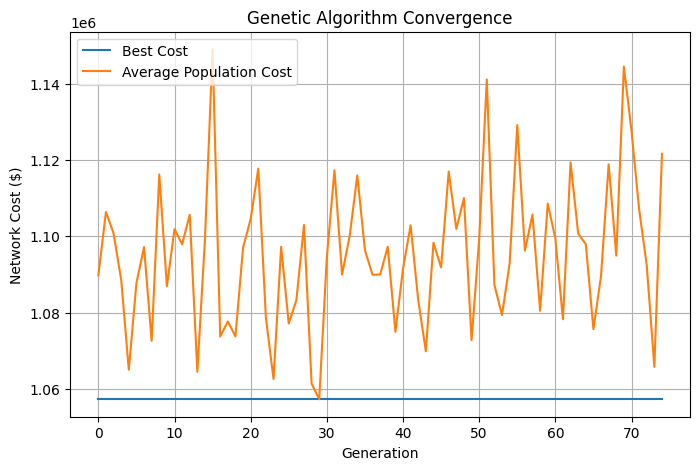

In [131]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(GENERATIONS),
    best_cost_history,
    label="Best Cost"
)

plt.plot(
    range(GENERATIONS),
    average_cost_history,
    label="Average Population Cost"
)

plt.xlabel("Generation")
plt.ylabel("Network Cost ($)")
plt.title("Genetic Algorithm Convergence")
plt.legend()
plt.grid(True)

plt.show()

# Step 8: Gradient-Based Optimization for inventory balancing

In [133]:
selected_dc = [
    "New York",
    "Los Angeles",
    "Chicago",
    "Dallas-Fort Worth",
    "Miami",
    "Seattle"
]

In [134]:
served_demand = (
    shipment_results2
    .groupby("warehouse")["units_shipped"]
    .sum()
    .reindex(selected_dc)
    .fillna(0)
)

served_demand

,units_shipped
warehouse,
New York,32890.0
Los Angeles,27024.0
Chicago,20836.0
Dallas-Fort Worth,25282.0
Miami,8508.0
Seattle,5461.0


In [135]:
target_inventory = served_demand.values * 1.10

target_inventory

array([36179. , 29726.4, 22919.6, 27810.2,  9358.8,  6007.1])

In [136]:
inventory = np.repeat(
    target_inventory.mean(),
    len(target_inventory)
)

print("Initial inventory:")
print(inventory)

print("\nTarget inventory:")
print(target_inventory)

Initial inventory:
[22000.18333333 22000.18333333 22000.18333333 22000.18333333
 22000.18333333 22000.18333333]

Target inventory:
[36179.  29726.4 22919.6 27810.2  9358.8  6007.1]


In [137]:
def inventory_cost(inventory, target):
    return np.sum((inventory - target) ** 2)

In [138]:
learning_rate = 0.05
iterations = 100

gd_cost_history = []

for iteration in range(iterations):

    # Gradient of sum((inventory - target)^2)
    gradient = 2 * (inventory - target_inventory)

    # Gradient descent update
    inventory = inventory - learning_rate * gradient

    cost = inventory_cost(
        inventory,
        target_inventory
    )

    gd_cost_history.append(cost)

In [139]:
inventory_results = pd.DataFrame({
    "warehouse": selected_dc,
    "target_inventory": target_inventory,
    "optimized_inventory": inventory,
    "difference": inventory - target_inventory
})

inventory_results

,warehouse,target_inventory,optimized_inventory,difference
0,New York,36179.0,36178.623391,-0.376609
1,Los Angeles,29726.4,29726.194781,-0.205219
2,Chicago,22919.6,22919.575579,-0.024421
3,Dallas-Fort Worth,27810.2,27810.045678,-0.154322
4,Miami,9358.8,9359.135773,0.335773
5,Seattle,6007.1,6007.524799,0.424799


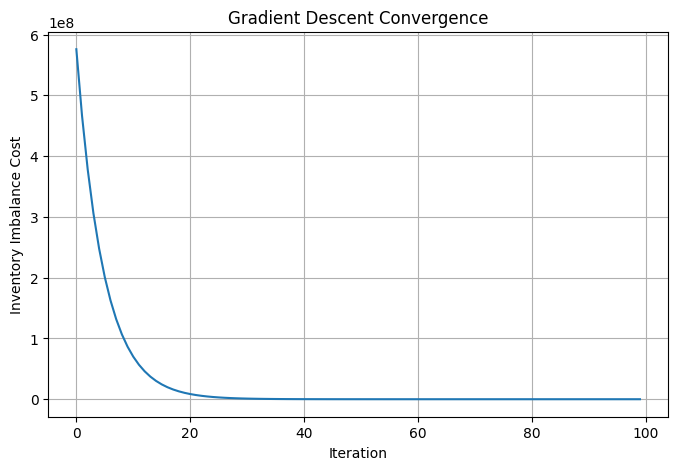

In [140]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(iterations),
    gd_cost_history
)

plt.xlabel("Iteration")
plt.ylabel("Inventory Imbalance Cost")
plt.title("Gradient Descent Convergence")

plt.grid(True)
plt.show()

In [141]:
initial_cost = gd_cost_history[0]
final_cost = gd_cost_history[-1]

print(f"Initial imbalance cost: {initial_cost:,.2f}")
print(f"Final imbalance cost: {final_cost:,.6f}")

improvement_pct = (
    (initial_cost - final_cost)
    / initial_cost
    * 100
)

print(f"Improvement: {improvement_pct:.2f}%")

Initial imbalance cost: 575,843,720.78
Final imbalance cost: 0.501558
Improvement: 100.00%


# Step 9: Sensitivity Analysis

A. Warehouse-count sensitivity

In [142]:
warehouse_sensitivity = []

for max_wh in [4, 5, 6, 7, 8]:

    test_model = pulp.LpProblem(
        f"Warehouse_Sensitivity_{max_wh}",
        pulp.LpMinimize
    )

    open_var = pulp.LpVariable.dicts(
        "Open",
        warehouses,
        cat="Binary"
    )

    ship_var = pulp.LpVariable.dicts(
        "Ship",
        (warehouses, customers),
        lowBound=0
    )

    test_model += (
        pulp.lpSum(
            fixed_cost[w] * open_var[w]
            for w in warehouses
        )
        +
        pulp.lpSum(
            transport_cost[(w, c)] * ship_var[w][c]
            for w in warehouses
            for c in customers
        )
    )

    for c in customers:
        test_model += (
            pulp.lpSum(
                ship_var[w][c]
                for w in warehouses
            )
            == demand[c]
        )

    for w in warehouses:
        test_model += (
            pulp.lpSum(
                ship_var[w][c]
                for c in customers
            )
            <= capacity[w] * open_var[w]
        )

    for w in warehouses:
        for c in customers:
            if not route_allowed[(w, c)]:
                test_model += ship_var[w][c] == 0

    test_model += (
        pulp.lpSum(open_var[w] for w in warehouses)
        <= max_wh
    )

    test_model.solve(
        pulp.PULP_CBC_CMD(msg=False)
    )

    status = pulp.LpStatus[test_model.status]

    warehouse_sensitivity.append({
        "max_warehouses": max_wh,
        "status": status,
        "total_cost":
            pulp.value(test_model.objective)
            if status == "Optimal"
            else None
    })

warehouse_sensitivity = pd.DataFrame(
    warehouse_sensitivity
)

warehouse_sensitivity

,max_warehouses,status,total_cost
0,4,Optimal,1.444978e+06
1,5,Optimal,1.198733e+06
2,6,Optimal,1.057299e+06
3,7,Optimal,9.313192e+05
4,8,Optimal,8.909218e+05


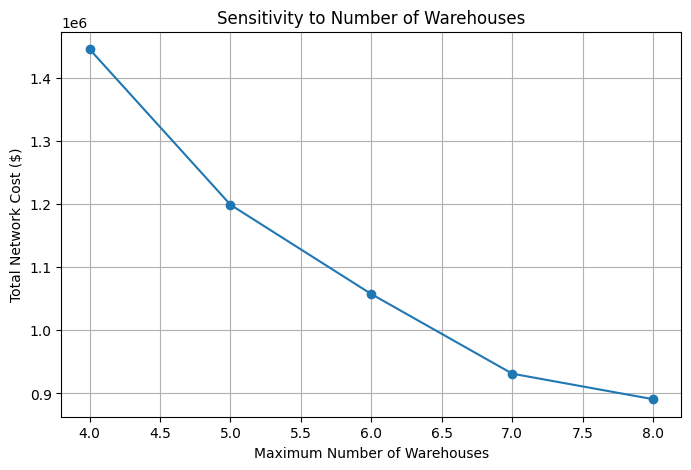

In [143]:
valid_wh = warehouse_sensitivity[
    warehouse_sensitivity["status"] == "Optimal"
]

plt.figure(figsize=(8, 5))

plt.plot(
    valid_wh["max_warehouses"],
    valid_wh["total_cost"],
    marker="o"
)

plt.xlabel("Maximum Number of Warehouses")
plt.ylabel("Total Network Cost ($)")
plt.title("Sensitivity to Number of Warehouses")
plt.grid(True)

plt.show()

B. Transportation-cost sensitivity

In [144]:
transport_sensitivity = []

for multiplier in [0.8, 1.0, 1.2]:

    test_model = pulp.LpProblem(
        f"Transport_Sensitivity_{multiplier}",
        pulp.LpMinimize
    )

    open_var = pulp.LpVariable.dicts(
        "Open",
        warehouses,
        cat="Binary"
    )

    ship_var = pulp.LpVariable.dicts(
        "Ship",
        (warehouses, customers),
        lowBound=0
    )

    test_model += (
        pulp.lpSum(
            fixed_cost[w] * open_var[w]
            for w in warehouses
        )
        +
        pulp.lpSum(
            transport_cost[(w, c)]
            * multiplier
            * ship_var[w][c]
            for w in warehouses
            for c in customers
        )
    )

    for c in customers:
        test_model += (
            pulp.lpSum(
                ship_var[w][c]
                for w in warehouses
            )
            == demand[c]
        )

    for w in warehouses:
        test_model += (
            pulp.lpSum(
                ship_var[w][c]
                for c in customers
            )
            <= capacity[w] * open_var[w]
        )

    for w in warehouses:
        for c in customers:
            if not route_allowed[(w, c)]:
                test_model += ship_var[w][c] == 0

    test_model += (
        pulp.lpSum(open_var[w] for w in warehouses)
        <= 6
    )

    test_model.solve(
        pulp.PULP_CBC_CMD(msg=False)
    )

    transport_sensitivity.append({
        "transport_multiplier": multiplier,
        "total_cost":
            pulp.value(test_model.objective)
    })

transport_sensitivity = pd.DataFrame(
    transport_sensitivity
)

transport_sensitivity

,transport_multiplier,total_cost
0,0.8,9.424017e+05
1,1.0,1.057299e+06
2,1.2,1.172197e+06


C. Demand sensitivity

In [145]:
demand_sensitivity = []

for multiplier in [1.0, 1.10, 1.20]:

    adjusted_demand = {
        c: demand[c] * multiplier
        for c in customers
    }

    test_model = pulp.LpProblem(
        f"Demand_Sensitivity_{multiplier}",
        pulp.LpMinimize
    )

    open_var = pulp.LpVariable.dicts(
        "Open",
        warehouses,
        cat="Binary"
    )

    ship_var = pulp.LpVariable.dicts(
        "Ship",
        (warehouses, customers),
        lowBound=0
    )

    test_model += (
        pulp.lpSum(
            fixed_cost[w] * open_var[w]
            for w in warehouses
        )
        +
        pulp.lpSum(
            transport_cost[(w, c)] * ship_var[w][c]
            for w in warehouses
            for c in customers
        )
    )

    for c in customers:
        test_model += (
            pulp.lpSum(
                ship_var[w][c]
                for w in warehouses
            )
            == adjusted_demand[c]
        )

    for w in warehouses:
        test_model += (
            pulp.lpSum(
                ship_var[w][c]
                for c in customers
            )
            <= capacity[w] * open_var[w]
        )

    for w in warehouses:
        for c in customers:
            if not route_allowed[(w, c)]:
                test_model += ship_var[w][c] == 0

    test_model += (
        pulp.lpSum(open_var[w] for w in warehouses)
        <= 6
    )

    test_model.solve(
        pulp.PULP_CBC_CMD(msg=False)
    )

    status = pulp.LpStatus[test_model.status]

    demand_sensitivity.append({
        "demand_multiplier": multiplier,
        "status": status,
        "total_cost":
            pulp.value(test_model.objective)
            if status == "Optimal"
            else None
    })

demand_sensitivity = pd.DataFrame(
    demand_sensitivity
)

demand_sensitivity

,demand_multiplier,status,total_cost
0,1.0,Optimal,1.057299e+06
1,1.1,Optimal,1.175318e+06
2,1.2,Optimal,1.319382e+06


# Step 10: Final Model Comparison

In [146]:
comparison = pd.DataFrame({
    "Method": [
        "MILP",
        "Genetic Algorithm",
        "Gradient Descent"
    ],

    "Optimization Role": [
        "Warehouse location and transportation",
        "Heuristic warehouse location",
        "Inventory balancing"
    ],

    "Result": [
        f"${MILP_COST:,.2f}",
        f"${best_cost:,.2f}",
        f"{final_cost:.4f} imbalance cost"
    ],

    "Optimality Guarantee": [
        "Yes",
        "No",
        "Depends on objective/convexity"
    ],

    "Key Finding": [
        "Optimal six-warehouse network",
        "Matched MILP optimum",
        "Inventory converged to target levels"
    ]
})

comparison

,Method,Optimization Role,Result,Optimality Guarantee,Key Finding
0,MILP,Warehouse location and transportation,"$1,057,299.18",Yes,Optimal six-warehouse network
1,Genetic Algorithm,Heuristic warehouse location,"$1,057,299.18",No,Matched MILP optimum
2,Gradient Descent,Inventory balancing,0.5016 imbalance cost,Depends on objective/convexity,Inventory converged to target levels


In [148]:
method_costs = pd.DataFrame({
    "Method": ["MILP", "Genetic Algorithm"],
    "Network Cost": [
        MILP_COST,
        best_cost
    ]
})

method_costs

,Method,Network Cost
0,MILP,1.057299e+06
1,Genetic Algorithm,1.057299e+06


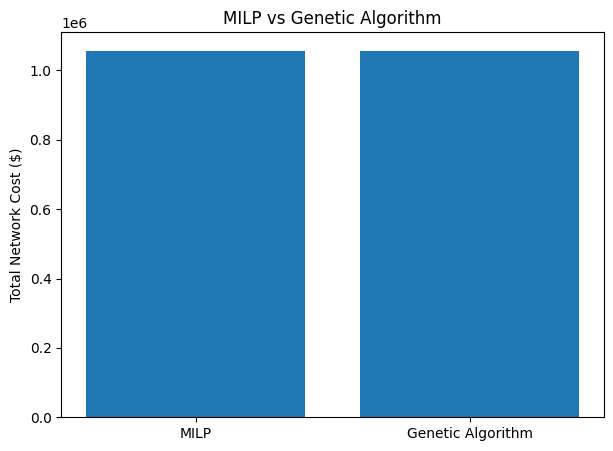

In [149]:
plt.figure(figsize=(7, 5))

plt.bar(
    method_costs["Method"],
    method_costs["Network Cost"]
)

plt.ylabel("Total Network Cost ($)")
plt.title("MILP vs Genetic Algorithm")

plt.show()

In [150]:
sensitivity_summary = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Transport Cost -20%",
        "Transport Cost +20%",
        "Demand +10%",
        "Demand +20%"
    ],

    "Total Network Cost": [
        MILP_COST,
        transport_sensitivity.loc[
            transport_sensitivity["transport_multiplier"] == 0.8,
            "total_cost"
        ].iloc[0],

        transport_sensitivity.loc[
            transport_sensitivity["transport_multiplier"] == 1.2,
            "total_cost"
        ].iloc[0],

        demand_sensitivity.loc[
            demand_sensitivity["demand_multiplier"] == 1.10,
            "total_cost"
        ].iloc[0],

        demand_sensitivity.loc[
            demand_sensitivity["demand_multiplier"] == 1.20,
            "total_cost"
        ].iloc[0]
    ]
})

sensitivity_summary

,Scenario,Total Network Cost
0,Baseline,1.057299e+06
1,Transport Cost -20%,9.424017e+05
2,Transport Cost +20%,1.172197e+06
3,Demand +10%,1.175318e+06
4,Demand +20%,1.319382e+06


In [151]:
sensitivity_summary["Change_vs_Baseline_%"] = (
    (
        sensitivity_summary["Total Network Cost"]
        - MILP_COST
    )
    / MILP_COST
    * 100
)

sensitivity_summary

,Scenario,Total Network Cost,Change_vs_Baseline_%
0,Baseline,1.057299e+06,0.000000
1,Transport Cost -20%,9.424017e+05,-10.867069
2,Transport Cost +20%,1.172197e+06,10.867070
3,Demand +10%,1.175318e+06,11.162281
4,Demand +20%,1.319382e+06,24.787922


In [152]:
print("MILP optimal cost:", f"${MILP_COST:,.2f}")
print("GA best cost:", f"${best_cost:,.2f}")
print("GA gap:", f"{ga_gap_pct:.2f}%")

print(
    "Gradient descent final imbalance:",
    f"{final_cost:.6f}"
)

print("\nSelected warehouses:")
for w in selected_warehouses2:
    print("-", w)

MILP optimal cost: $1,057,299.18
GA best cost: $1,057,299.18
GA gap: 0.00%
Gradient descent final imbalance: 0.501558

Selected warehouses:
- New York
- Los Angeles
- Chicago
- Dallas-Fort Worth
- Miami
- Seattle
